In [44]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

cwd = os.getcwd()
if cwd.endswith('notebook'):
    os.chdir('..')
    cwd = os.getcwd()

In [2]:
sns.set_palette('colorblind')
sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.8)
plt.rcParams['font.family'] = 'Helvetica'

palette = sns.color_palette().as_hex()

data_folder = Path('./data')
assert data_folder.is_dir()

figures_folder = Path('./figures')
assert figures_folder.is_dir()

In [3]:
gtdb_metadata = pd.read_csv(data_folder / 'gtdb_metadata.csv', index_col='ncbi_accession')

In [83]:
pgh_proteins = pd.read_csv(data_folder / 'pgh_proteins.csv')
pgh_proteins['id'] = pgh_proteins.apply(lambda row: f"{row['protein_id']}@{row['assembly_accession']}", axis=1)
pgh_proteins.head()

,assembly_accession,domain,gtdb_phylum,gtdb_class,gtdb_order,gtdb_family,gtdb_genus,gtdb_species,ncbi_organism_name,protein_id,pgh_architecture,id
0,GCA_003663345.1,Archaea,Aenigmatarchaeota,Aenigmatarchaeia,PWEA01,B50-G16,B50-G16,B50-G16 sp003663345,Candidatus Aenigmarchaeota archaeon,RLJ01288.1,PG_binding_3+Glyco_hydro_108,RLJ01288.1@GCA_003663345.1
1,GCA_018304545.1,Archaea,Aenigmatarchaeota,Aenigmatarchaeia,CG10238-14,CG10238-14,JAGVVZ01,JAGVVZ01 sp018304545,Candidatus Aenigmarchaeota archaeon,MBS3052716.1,LysM+Amidase_2,MBS3052716.1@GCA_018304545.1
2,GCA_025058005.1,Archaea,Aenigmatarchaeota,Aenigmatarchaeia,CG10238-14,CG10238-14,JAHLMN01,JAHLMN01 sp025058005,Candidatus Aenigmarchaeota archaeon,MCS7135447.1,LysM+NLPC_P60,MCS7135447.1@GCA_025058005.1
3,GCA_015661515.1,Archaea,Aenigmatarchaeota,Aenigmatarchaeia,Aenigmatarchaeales,SZUA-1535,SZUA-1535,SZUA-1535 sp015661515,Nanoarchaeota archaeon,HIQ49991.1,PG_binding_3+Glyco_hydro_108,HIQ49991.1@GCA_015661515.1
4,GCA_902384455.1,Archaea,Altiarchaeota,Altiarchaeia,IMC4,SCGC-AAA252-I15,CABMCB01,CABMCB01 sp902384455,uncultured archaeon,VVB52780.1,PG_binding_3+Glyco_hydro_108,VVB52780.1@GCA_902384455.1


In [80]:
signalp = pd.read_csv(data_folder / 'halobacteria_bias' / 'Halobacteria_signalp6_output.csv')
signalp = signalp.rename(columns={'protein_id': 'id'})
assert len(signalp['id'].unique()) == len(signalp)
signalp.head()

,id,signal_peptide,probability,cleavage_site,cleavage_site_prob
0,AEN04494.1@GCA_000224475.1,Tat/SPII,0.999882,26-27,0.851422
1,AEN04510.1@GCA_000224475.1,Tat/SPII,0.999904,21-22,0.847711
2,AEN04532.1@GCA_000224475.1,Sec/SPII,0.980347,15-16,0.954845
3,AEN04547.1@GCA_000224475.1,Sec/SPI,0.739303,28-29,0.702220
4,AEN04548.1@GCA_000224475.1,Sec/SPI,0.998561,24-25,0.959543


## Export Halobacteria genome accessions

In [4]:
halobacterial_genomes = sorted(set(gtdb_metadata[gtdb_metadata['gtdb_class'] == 'Halobacteria'].index))
pd.DataFrame.from_dict({
    'id': halobacterial_genomes,
}).to_csv(data_folder / 'halobacteria_bias' / 'halobacteria_ids.txt', index=False, header=None)

## Process results

From script `src/run_pi_aa_bias.py`

In [84]:
bias_df = pd.read_csv(data_folder / 'halobacteria_bias' / 'Halobacteria_proteins_pI_aa.csv.gz')
bias_df['assembly_accession'] = bias_df['id'].apply(lambda v: v.split('@')[1])
bias_df = pd.merge(
    bias_df,
    signalp[['id', 'signal_peptide']],
    on='id',
    how='left',
)
bias_df = pd.merge(
    bias_df,
    pgh_proteins[['id', 'pgh_architecture']],
    on='id',
    how='left',
)
bias_df = bias_df.sort_values(['assembly_accession', 'id']).set_index('assembly_accession')
bias_df.head()

,id,protein_length,molecular_weight,pI,A,C,D,E,F,G,...,P,Q,R,S,T,V,W,Y,signal_peptide,pgh_architecture
assembly_accession,,,,,,,,,,,,,,,,,,,,,
GCA_000224475.1,AEN04491.1@GCA_000224475.1,367,38910.57,4.33,70,2,26,36,10,26,...,25,8,28,20,25,32,6,10,NaN,NaN
GCA_000224475.1,AEN04492.1@GCA_000224475.1,752,81939.87,4.38,94,4,63,68,24,54,...,36,24,44,26,45,56,0,21,NaN,NaN
GCA_000224475.1,AEN04493.1@GCA_000224475.1,89,9192.30,4.74,9,0,3,5,3,9,...,7,3,5,11,7,11,1,1,NaN,NaN
GCA_000224475.1,AEN04494.1@GCA_000224475.1,536,58473.76,4.02,38,2,43,47,22,42,...,25,29,24,46,40,42,6,10,Tat/SPII,NaN
GCA_000224475.1,AEN04495.1@GCA_000224475.1,330,35705.18,8.35,29,0,12,9,14,32,...,16,12,17,13,27,31,5,12,NaN,NaN


### pI

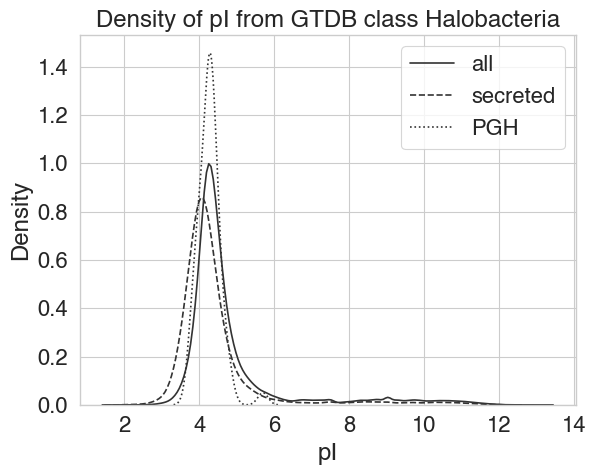

In [142]:
ax = sns.kdeplot(bias_df['pI'].values, color='#333333', label='all', common_norm=True)
sns.kdeplot(bias_df[bias_df['signal_peptide'].notnull()]['pI'].values, color='#333333', label='secreted', linestyle='dashed', ax=ax)
sns.kdeplot(bias_df[bias_df['pgh_architecture'].notnull()]['pI'].values, color='#333333', label='PGH', linestyle='dotted', ax=ax)

ax.set_xlabel('pI');
ax.set_title('Density of pI from GTDB class Halobacteria');
ax.legend();

plt.gcf().savefig(figures_folder / 'halobacteria_bias' / 'Halobacteria_pI.pdf', dpi=300, bbox_inches='tight');

### Amino acid bias

In [136]:
def compute_aa_bias(bias_df, name='AA_percent'):
    AAs = [v for v in 'ACDEFGHIKLMNPQRSTVWY']
    aa_bias = bias_df[['protein_length'] + AAs].sum()
    aa_bias = aa_bias / aa_bias['protein_length']
    aa_bias = (100 * pd.DataFrame([aa_bias]).drop(columns=['protein_length']).transpose()).round(2)
    aa_bias.index.names = ['AA']
    aa_bias.columns = [name]
    return aa_bias

In [137]:
aa_bias = pd.concat([
    compute_aa_bias(bias_df, 'all'),
    compute_aa_bias(bias_df[bias_df['signal_peptide'].notnull()], 'secreted'),
    compute_aa_bias(bias_df[bias_df['pgh_architecture'].notnull()], 'pgh'),
], axis=1).sort_values('all')
aa_bias

,all,secreted,pgh
AA,,,
C,0.73,0.55,1.04
W,1.14,1.31,1.79
M,1.73,1.35,1.17
K,1.84,1.30,1.02
H,2.01,1.59,2.13
N,2.37,3.43,2.57
Q,2.51,2.81,2.75
Y,2.70,2.89,3.95
F,3.31,3.05,2.09


In [138]:
aa_bias.sort_values('all', ascending=False).to_csv(data_folder / 'halobacteria_bias' / 'Halobacteria_aa_bias_summary.csv')

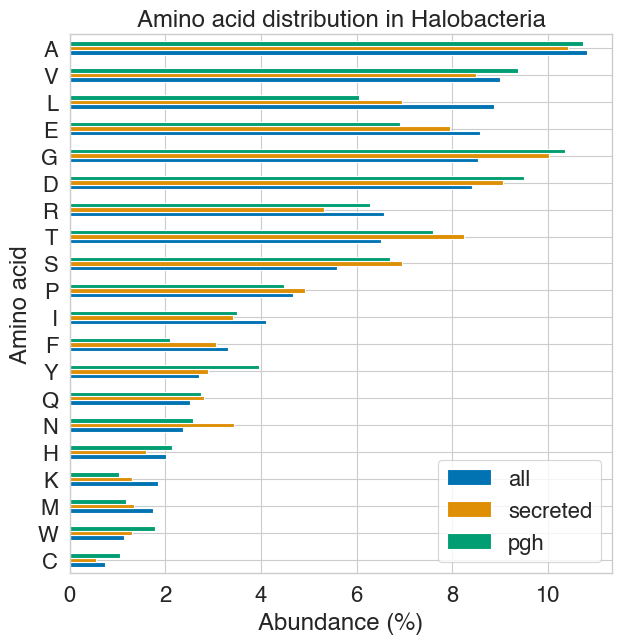

In [143]:
ax = aa_bias.plot.barh(figsize=(7, 7), legend=True);
ax.set_ylabel('Amino acid');
ax.set_xlabel('Abundance (%)');
ax.set_title('Amino acid distribution in Halobacteria');

plt.gcf().savefig(figures_folder / 'halobacteria_bias' / 'Halobacteria_AA_dist.pdf', dpi=300, bbox_inches='tight');